In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
df = pd.read_csv("/content/drive/MyDrive/BIA Internship/Project 2/usedCars.csv")
df.head(5)

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


In [87]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-n

In [88]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                  Id      Kilometer    ModelYear     Warranty  QualityScore
count    1064.000000    1064.000000  1064.000000  1064.000000   1064.000000
mean   568156.542293   52807.187970  2016.864662     0.738722      7.770207
std     16438.139974   33840.296979     2.996786     0.439538      0.719717
min    525978.000000     101.000000  2003.000000     0.000000      0.000000
25%    555321.500000   32113.500000  2015.000000     0.000000      7.500000
50%    572753.000000   49432.000000  2017.000000     1.000000      7.800000
75%    583072.750000   68828.500000  2019.000000     1.000000      8.100000
max    589122.000000  640000.000000  2023.000000     1.000000      9.400000


In [89]:
# missing values
mv= df.isnull().sum()
print(mv)

Id                     0
Company                0
Model                  0
Variant                0
FuelType               1
Colour                 0
Kilometer              0
BodyStyle              0
TransmissionType     714
ManufactureDate        0
ModelYear              0
CngKit              1042
Price                  0
Owner                  0
DealerState            0
DealerName             0
City                   0
Warranty               0
QualityScore           0
dtype: int64


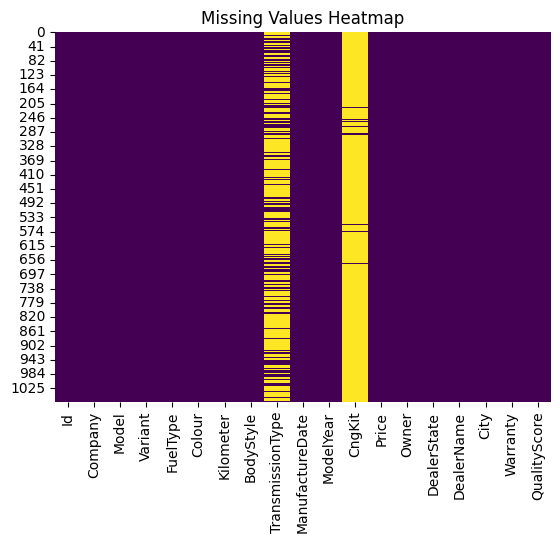

In [90]:
# Visualizing Missing Values
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [91]:
# Handling Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(df.mode().iloc[0], inplace=True)


In [92]:
mv= df.isnull().sum()
print(mv)

Id                  0
Company             0
Model               0
Variant             0
FuelType            0
Colour              0
Kilometer           0
BodyStyle           0
TransmissionType    0
ManufactureDate     0
ModelYear           0
CngKit              0
Price               0
Owner               0
DealerState         0
DealerName          0
City                0
Warranty            0
QualityScore        0
dtype: int64


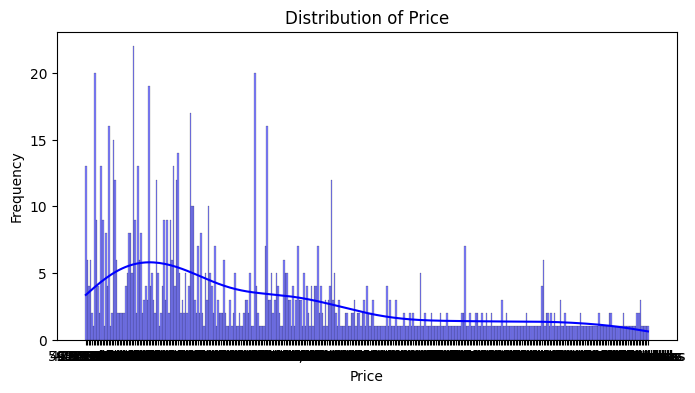

In [93]:
# Distribution of Target Variable (Price)
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, bins=30, color='blue')
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

<ipython-input-94-95c0edf1a48c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')


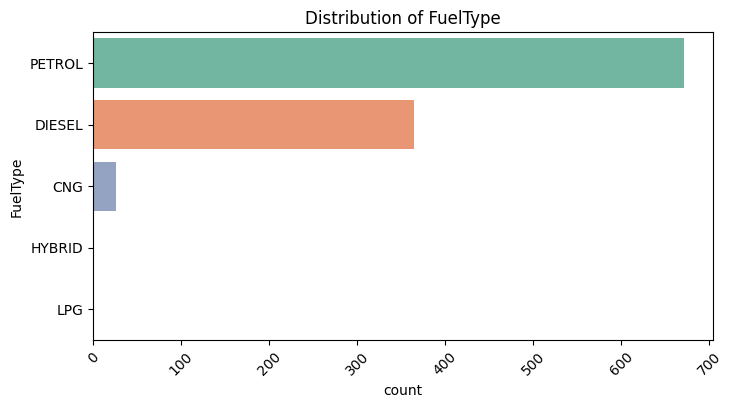

<ipython-input-94-95c0edf1a48c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')


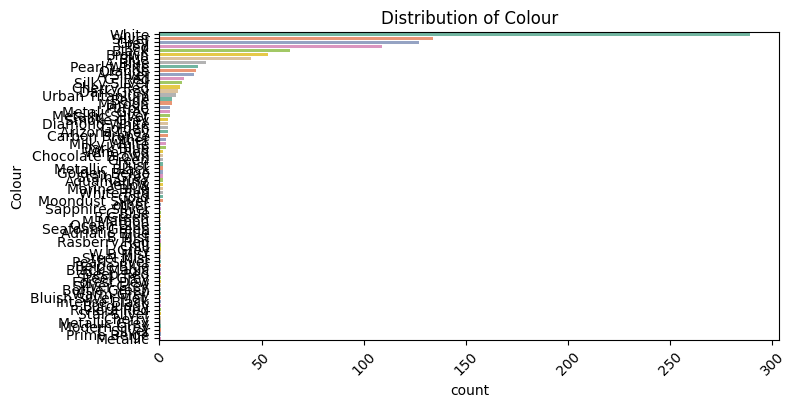

<ipython-input-94-95c0edf1a48c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')


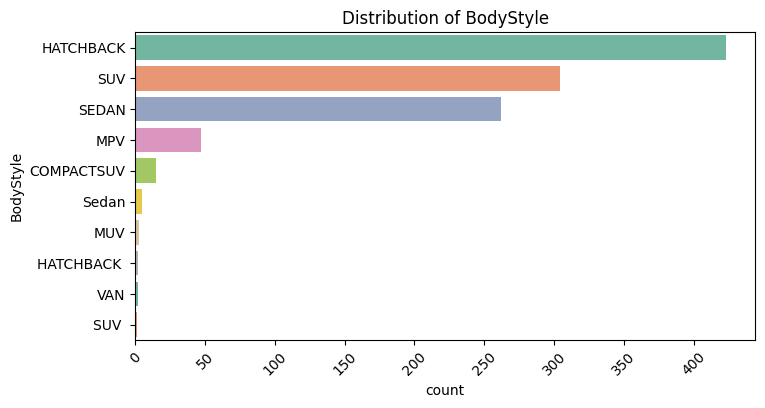

<ipython-input-94-95c0edf1a48c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')


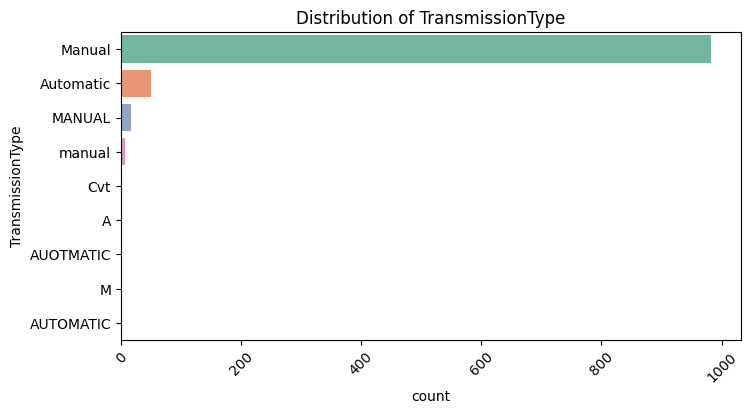

<ipython-input-94-95c0edf1a48c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')


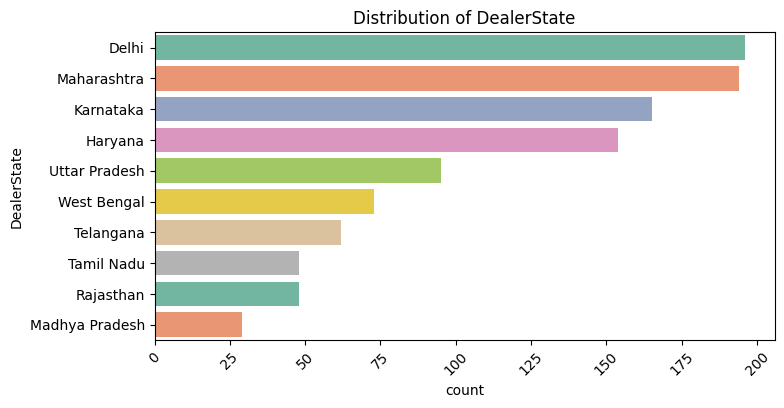

<ipython-input-94-95c0edf1a48c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')


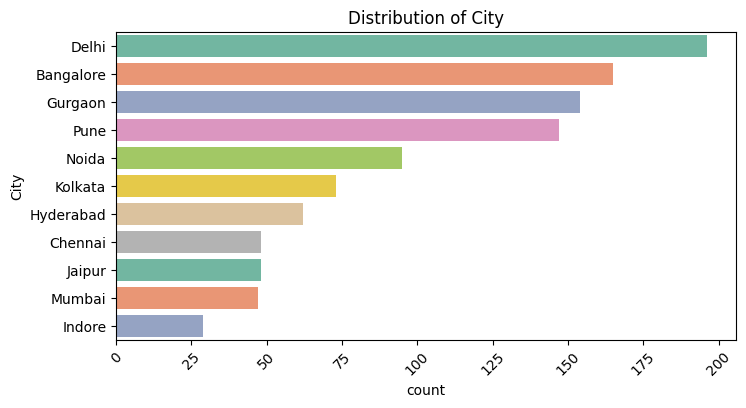

In [94]:
# Categorical Feature Analysis
categorical_columns = ['FuelType', 'Colour', 'BodyStyle', 'TransmissionType', 'DealerState', 'City']
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(df[col], order=df[col].value_counts().index, palette='Set2')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

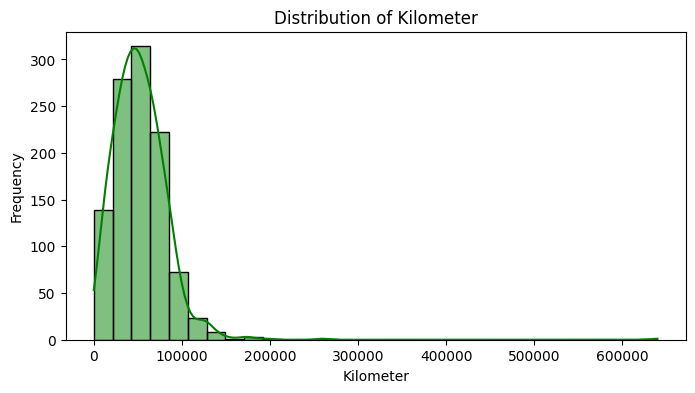

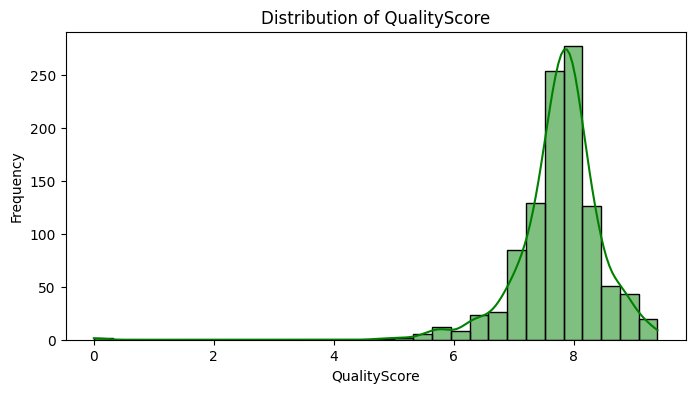

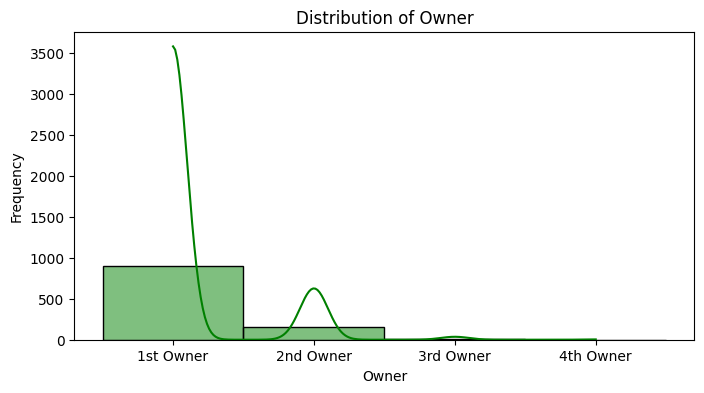

In [95]:
# Numerical Feature Analysis
numerical_columns = ['Kilometer', 'QualityScore', 'Owner']
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30, color='green')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

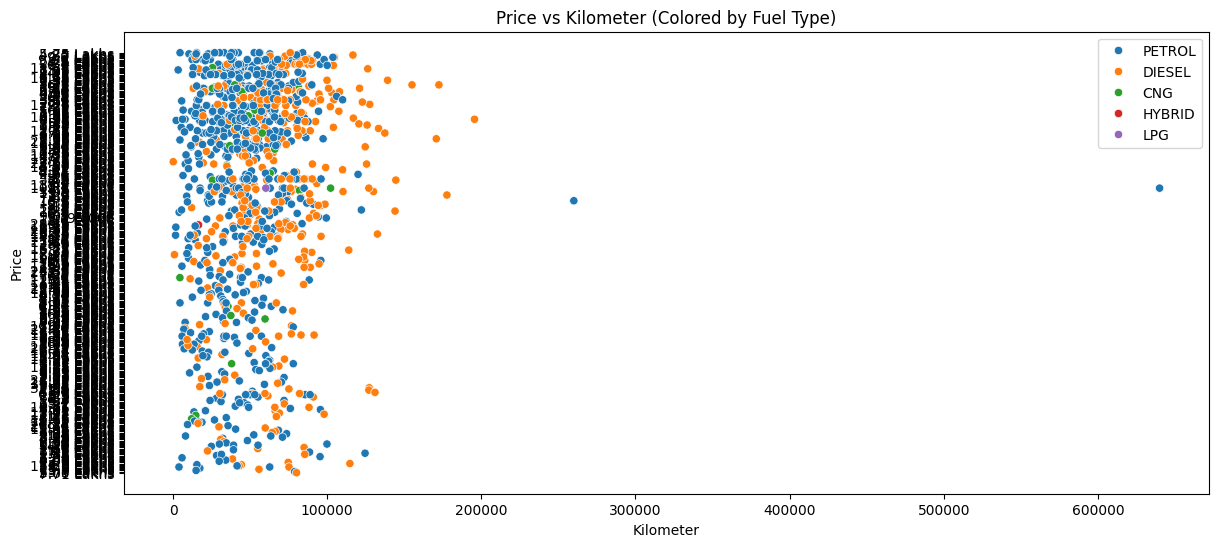

In [96]:
# Scatter Plot: Price vs Kilometer
plt.figure(figsize=(14, 6))
sns.scatterplot(x=df['Kilometer'], y=df['Price'], hue=df['FuelType'])
plt.title("Price vs Kilometer (Colored by Fuel Type)")
plt.xlabel("Kilometer")
plt.ylabel("Price")
plt.legend()
plt.show()

<ipython-input-97-ff0ba723d4b9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Price', data=df, palette='Set3')


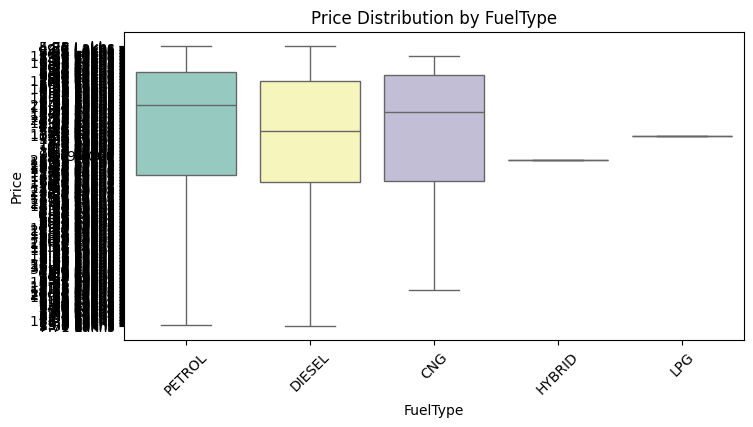

<ipython-input-97-ff0ba723d4b9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Price', data=df, palette='Set3')


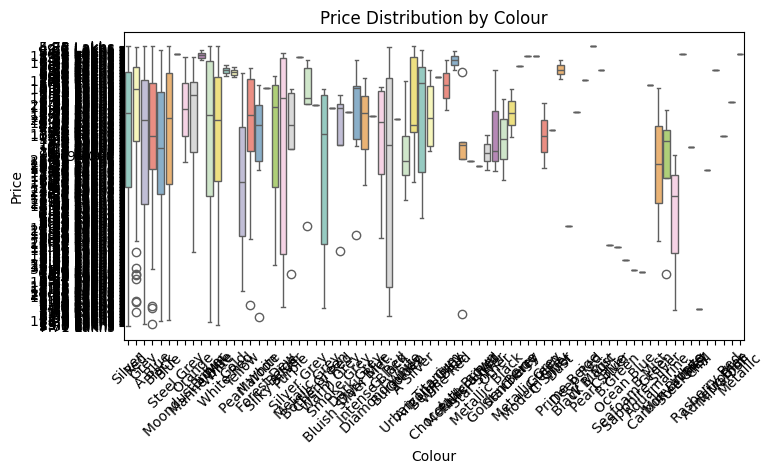

<ipython-input-97-ff0ba723d4b9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Price', data=df, palette='Set3')


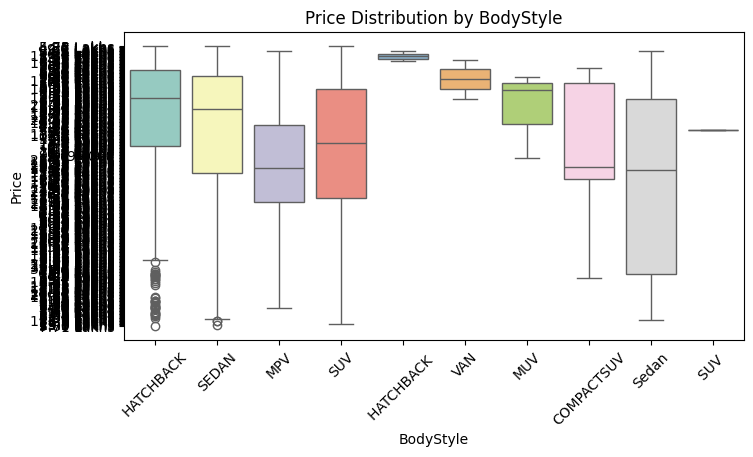

<ipython-input-97-ff0ba723d4b9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Price', data=df, palette='Set3')


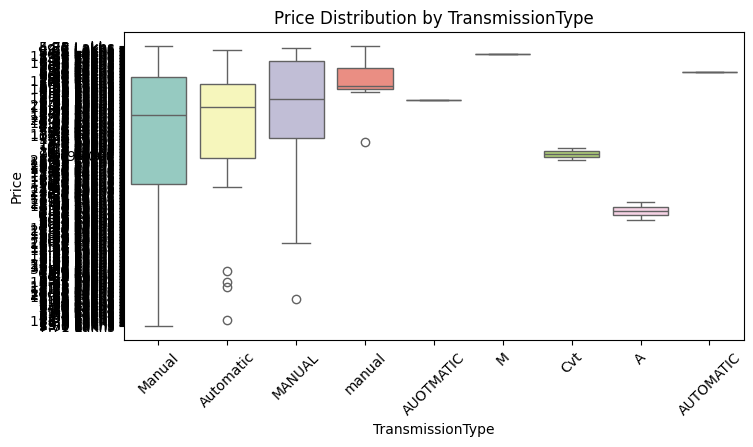

<ipython-input-97-ff0ba723d4b9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Price', data=df, palette='Set3')


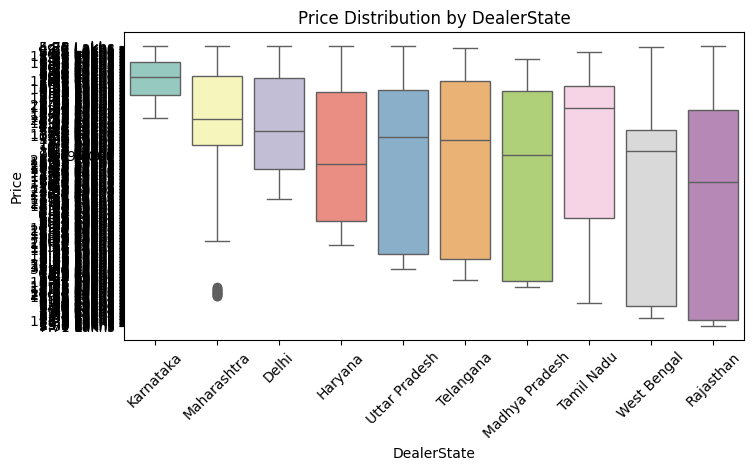

<ipython-input-97-ff0ba723d4b9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Price', data=df, palette='Set3')


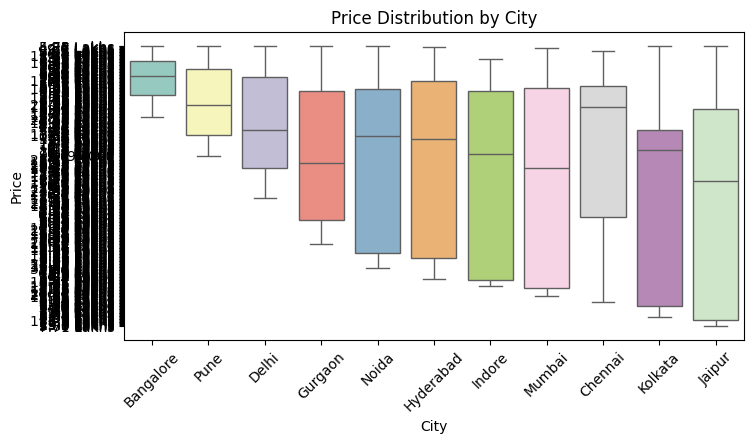

In [97]:
# Boxplots for Price based on Categorical Features
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y='Price', data=df, palette='Set3')
    plt.title(f"Price Distribution by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [103]:
# One-Hot Encoding for Categorical Variables
categorical_columns = ['FuelType', 'Colour', 'BodyStyle', 'TransmissionType', 'DealerState', 'City', 'Company', 'Model', 'Variant', 'ManufactureDate', 'CngKit', 'Owner', 'DealerName']
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

In [104]:
def convert_to_numeric(value):
  try:
    value = value.replace(',', '')  # Remove commas from the string"
    if 'Lakhs' in value:  # Check if the string contains the term 'Lakhs'
        return int(float(value.replace('Lakhs', '').strip()) * 1e5)  # Process and convert to integer
    elif value.isdigit():  # Case 2: Value is already numeric but in string format
        return int(value)
    else:
        return int(float(value))  # Convert other numeric formats to an integer
  except ValueError:
        raise ValueError(f"Unable to convert value: {value}")


df['Price'] = df['Price'].apply(convert_to_numeric)



In [105]:
df['Price'] = df['Price'].astype(int)
print(df['Price'].dtype)

int64


In [106]:
# Feature Selection
X = df.drop(columns=['Price'])  # Replace 'Price' with the actual target column name in your dataset
y = df['Price']                # Replace 'Price' with the actual target column name in your dataset



In [107]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
# Scaling for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

In [111]:
# Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)


In [125]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regressor

dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)  # Adjust max_depth for complexity
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

In [112]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Metrics:")
    print("Mean Absolute Error (MAE):", mean_absolute_error(y_true, y_pred))
    print("Mean Squared Error (MSE):", mean_squared_error(y_true, y_pred))
    print("R² Score:", r2_score(y_true, y_pred))

In [126]:
# Evaluate Both Models
evaluate_model(y_test, lr_predictions, "Linear Regression")
evaluate_model(y_test, rf_predictions, "Random Forest Regressor")
evaluate_model(y_test, dt_predictions, "Decision Tree Regressor")


Linear Regression Metrics:
Mean Absolute Error (MAE): 3.2060230643220357e+19
Mean Squared Error (MSE): 4.251146610941803e+39
R² Score: -1.7769152323667705e+28

Random Forest Regressor Metrics:
Mean Absolute Error (MAE): 171127.9564788732
Mean Squared Error (MSE): 122461399725.43768
R² Score: 0.48812980011320284

Decision Tree Regressor Metrics:
Mean Absolute Error (MAE): 238110.42207833426
Mean Squared Error (MSE): 388906891534.9132
R² Score: -0.6255722109468767


In [127]:
# Feature Importance (Random Forest and Decision Tree)
print("\nFeature Importances from Random Forest:")
rf_feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(rf_feature_importances)

print("\nFeature Importances from Decision Tree:")
dt_feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(dt_feature_importances)


Feature Importances from Random Forest:
                            Feature  Importance
84              BodyStyle_HATCHBACK    0.176552
2                         ModelYear    0.151529
802                Variant_V PETROL    0.068506
89                    BodyStyle_SUV    0.055385
227                  Model_FORTUNER    0.038112
..                              ...         ...
74                Colour_Steel Grey    0.000000
580            Variant_GTX PLUS 1.4    0.000000
585  Variant_HIGHLINE 1.0L PLUS (P)    0.000000
589         Variant_HIGHLINE 1.5L D    0.000000
598                 Variant_HTK 1.5    0.000000

[1154 rows x 2 columns]

Feature Importances from Decision Tree:
                        Feature  Importance
84          BodyStyle_HATCHBACK    0.232148
2                     ModelYear    0.159505
101         DealerState_Haryana    0.155934
227              Model_FORTUNER    0.050507
802            Variant_V PETROL    0.048154
...                         ...         ...
431      

In [128]:
# Residual Plots
plt.figure(figsize=(18, 6))

<Figure size 1800x600 with 0 Axes>

<Figure size 1800x600 with 0 Axes>

Text(0, 0.5, 'Residuals')

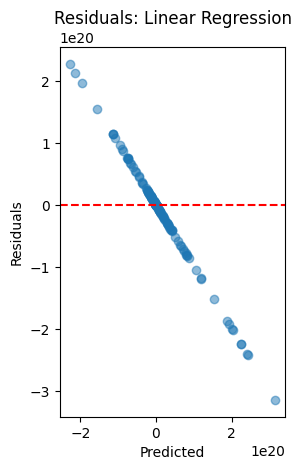

In [129]:
plt.subplot(1, 2, 1)
plt.scatter(lr_predictions, y_test - lr_predictions, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals: Linear Regression")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

Text(0, 0.5, 'Residuals')

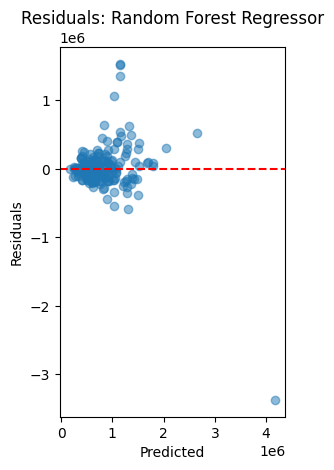

In [131]:
plt.subplot(1, 2, 2)
plt.scatter(rf_predictions, y_test - rf_predictions, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals: Random Forest Regressor")
plt.xlabel("Predicted")
plt.ylabel("Residuals")


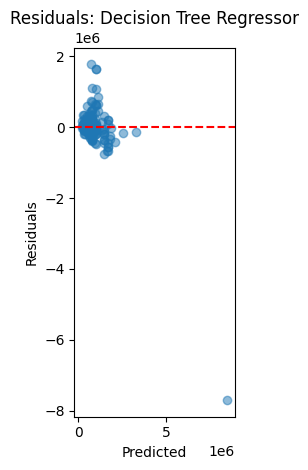

In [132]:
# Residuals for Decision Tree
plt.subplot(1, 3, 3)
plt.scatter(dt_predictions, y_test - dt_predictions, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals: Decision Tree Regressor")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()